In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from pathlib import Path

In [39]:
# TODO: think about the number of iterations -> potential scaling issues with lots of agents
# TODO: introduce the option to intervene in the market i.e. changing the reservation price schedule while matining the same histories

# Load the data

In [2]:
# select the experiment for which you want to analyse data
experiment_id = "test_20260207_144528"

In [3]:
# set the paths
root_path = Path(globals()['_dh'][0]).parent
results_path = root_path / 'results' / experiment_id

# read the number of simulations from the config file
with open(results_path / 'config_used.yaml', "r") as f:
    config = yaml.safe_load(f)
n_sims = config['experiment']['n_simulations']

# read the results data for all simulations
iteration_histories = [pd.read_csv(results_path / 'data' / f'iteration_history_{sim+1}.csv')
                       for sim in range(n_sims)]

agents_histories = [pd.read_csv(results_path / 'data' / f'agent_histories_{sim+1}.csv')
                    for sim in range(n_sims)]

# combine multiple simulations into a single dataframe
df_data_all = pd.concat(
    [df.assign(sim=i+1) for i, df in enumerate(iteration_histories)],
    ignore_index=True
)
df_data_agents_all = pd.concat(
    [df.assign(sim=i+1) for i, df in enumerate(agents_histories)],
    ignore_index=True
)

In [4]:
df_data_all

,round,iteration,price,announcement_made,transaction_made,announcement_type,announcing_agent_id,announcing_agent_reservation_price,responding_agent_id,responding_agent_reservation_price,sim
0,1,1,1.0,True,True,buy,0.0,1.0,3,1.0,1
1,1,2,1.5,True,True,sell,4.0,1.5,2,2.0,1
2,1,3,1.4,True,False,buy,1.0,1.5,5,2.0,1
3,1,3,2.0,True,False,sell,5.0,2.0,1,1.5,1
4,1,3,NaN,False,False,sell,NaN,NaN,1,1.5,1
...,...,...,...,...,...,...,...,...,...,...,...
129,5,2,1.5,True,False,buy,1.0,1.5,5,2.0,2
130,5,2,1.5,True,True,buy,1.0,1.5,3,1.0,2
131,5,3,1.0,True,False,buy,0.0,1.0,5,2.0,2
132,5,3,2.0,True,False,sell,5.0,2.0,0,1.0,2


# Calculate the Equilibrium Price/Quantity for the experiment

In [5]:
def find_equilibrium(supply, demand, flat_threshold=1e-10):
    """
    Find equilibrium quantity and price where demand >= supply.
    
    Parameters:
        supply: array of supply prices at each quantity
        demand: array of demand prices at each quantity
        flat_threshold: tolerance for considering a curve "flat"
    
    Returns:
        q_eq: equilibrium quantity (number of trades)
        p_eq: equilibrium price
        p_supply: supply price at last trade
        p_demand: demand price at last trade
    """
    supply = np.asarray(supply)
    demand = np.asarray(demand)
    
    n = min(len(supply), len(demand))
    
    # Find last index where demand >= supply
    viable_mask = demand[:n] >= supply[:n]
    
    if not viable_mask.any():
        return 0, None, None, None
    
    last_idx = np.flatnonzero(viable_mask)[-1]
    next_idx = last_idx + 1
    
    q_eq = last_idx + 1
    p_supply = supply[last_idx]
    p_demand = demand[last_idx]
    
    # Check what happens at the next quantity unit
    has_next_supply = next_idx < len(supply)
    has_next_demand = next_idx < len(demand)
    
    # Determine price based on curve behavior at equilibrium
    if not has_next_supply:
        # Supply is vertical (ran out) - price based on demand side
        p_eq = (p_demand + demand[next_idx]) / 2 if has_next_demand else p_demand
    elif not has_next_demand:
        # Demand is vertical (ran out) - price based on supply side
        p_eq = (p_supply + supply[next_idx]) / 2 if has_next_supply else p_supply
    elif abs(supply[next_idx] - p_supply) < flat_threshold:
        # Supply is flat (perfectly elastic) - use supply price
        p_eq = p_supply
    elif abs(demand[next_idx] - p_demand) < flat_threshold:
        # Demand is flat (perfectly elastic) - use demand price
        p_eq = p_demand
    else:
        # Both curves have slope - use midpoint
        p_eq = (p_supply + p_demand) / 2
    
    return q_eq, p_eq

In [6]:
def plot_equilibrium(supply, demand, q_eq, p_eq, title=None, ax=None):
    """
    Visualize supply and demand curves with equilibrium point.
    
    Parameters:
        supply: array of supply prices at each quantity
        demand: array of demand prices at each quantity
        q_eq: equilibrium quantity
        p_eq: equilibrium price
        title: optional plot title
        ax: optional matplotlib axes (creates new figure if None)
    
    Returns:
        matplotlib axes object
    """
    supply = np.asarray(supply)
    demand = np.asarray(demand)
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    
    quantities_supply = np.arange(len(supply)) + 1
    quantities_demand = np.arange(len(demand)) + 1
    
    ax.step(quantities_supply, supply, 'b-', where='pre', label='Supply', linewidth=2)
    ax.step(quantities_demand, demand, 'r-', where='pre', label='Demand', linewidth=2)
    
    y_max = max(supply[-1], demand[0]) * 1.2
    
    # Extend supply vertically upward
    ax.vlines(len(supply), supply[-1], y_max, colors='blue', linewidth=2)
    
    # Extend demand vertically downward
    ax.vlines(len(demand), demand[-1], 0, colors='red', linewidth=2)
    
    if q_eq > 0 and p_eq is not None:
        ax.plot(q_eq, p_eq, 'go', markersize=12,
                label=f'Equilibrium: Q={q_eq}, P={p_eq:.2f}', zorder=5)
        ax.axhline(p_eq, color='green', linestyle=':', alpha=0.5, linewidth=1.5)
        ax.axvline(q_eq, color='green', linestyle='--', alpha=0.5, linewidth=1.5)
    
    ax.set_xlabel('Quantity')
    ax.set_ylabel('Price')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_title(title or 'Supply and Demand - Equilibrium')
    ax.set_ylim(0, y_max)
    
    return ax


In [7]:
# extract the demand and supply schedules from the config
demand = np.round(
    np.linspace(
        config["experiment"]["buyers"]["max"],
        config["experiment"]["buyers"]["min"],
        config["experiment"]["buyers"]["num"],
    ),
    2,
)
supply = np.round(
    np.linspace(
        config["experiment"]["sellers"]["min"],
        config["experiment"]["sellers"]["max"],
        config["experiment"]["sellers"]["num"],
    ),
    2,
)
# calculate the equilibrium price and quantity
q_eq, p_eq = find_equilibrium(supply=supply, demand=demand)
print(f"Equilibrium quantity: {q_eq}")
print(f"Equilibrium price: ${p_eq}")

# store in the results dataframe
df_data_all["equilibrium_price"] = p_eq
df_data_all["equilibrium_quantity"] = q_eq

Equilibrium quantity: 2
Equilibrium price: $1.5


<Axes: title={'center': 'Supply and Demand - Equilibrium'}, xlabel='Quantity', ylabel='Price'>

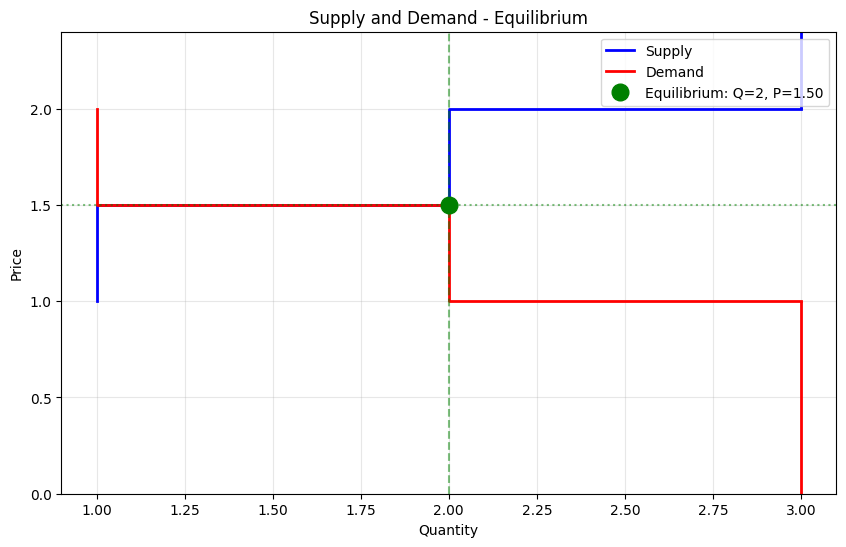

In [8]:
# plot the supply and demand curves and show the equilibrium
plot_equilibrium(supply, demand, q_eq, p_eq)

# Market-Wide Analysis

## Convergence to Theoretical Equilibrium

In [9]:
def calculate_coefficient_of_convergence(prices: np.ndarray, equilibrium_price: float):
    """Calculates the coefficient of convergene of prices to equilibrium (alpha) from the Smith (1962) paper.
    
    Parameters:
        prices: array of prices within a round
        equilibrium_price: theoretical equilibrium price    
    Returns:
        alpha: coefficient of convergene
    """
    squared_deviations = (prices - equilibrium_price)**2 
    var = squared_deviations.sum()/len(prices)
    std = var**0.5
    alpha = 100*std/equilibrium_price
    return alpha

df_transactions_all = df_data_all.loc[df_data_all['transaction_made']==True].reset_index()
coefficients_of_convergence = df_transactions_all.groupby(['sim', 'round'])['price'].agg(
    lambda prices: calculate_coefficient_of_convergence(prices.values, equilibrium_price=p_eq)
).reset_index(name='coefficient_of_convergence')

### Single Simulation Graph, Smith (1962)

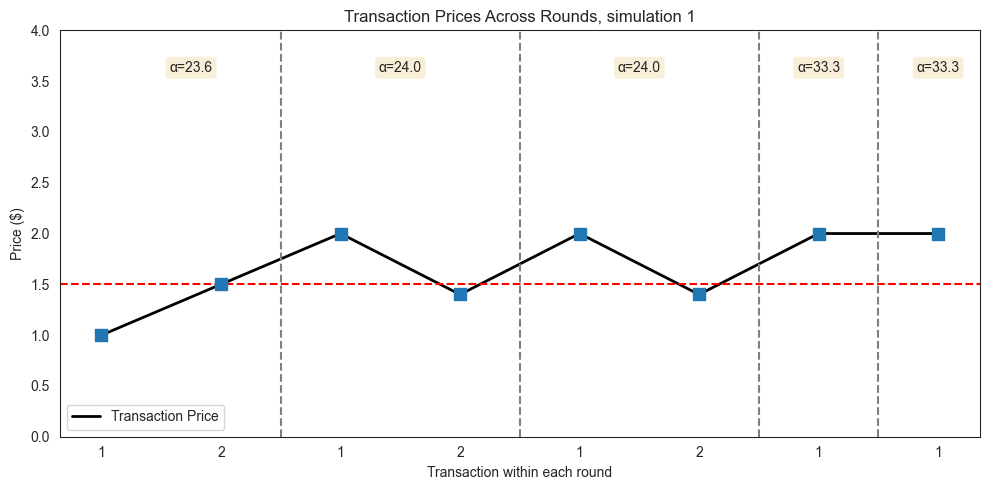

In [ ]:
# choose a simulation to plot
sim = 1

df_plot = df_data_all.loc[df_data_all['sim']==sim]
df_plot = df_plot[df_plot['transaction_made'] == True].reset_index()
df_plot['transaction_number'] = df_plot.groupby('round').cumcount() + 1

plt.figure(figsize=(10, 5))
# --- Line connecting all transactions ---
if len(df_plot) > 0:
    plt.plot(
        df_plot.index,
        df_plot['price'], 
        color='black',
        linewidth=2,
        label='Transaction Price',
        zorder=2
    )

    # --- markers ---
    plt.scatter(
        df_plot.index, 
        df_plot['price'], 
        marker='s', 
        s=80,
        color='#1f77b4',
        zorder=3
    )

# --- Formatting ---
last_indices_in_round = df_plot.groupby('round')['transaction_number'].apply(lambda g: g.index.max())
for x in last_indices_in_round[:-1]:
    plt.axvline(x=x+0.5, color='grey', linestyle='--', linewidth=1.5)

# --- Add alpha values for each round ---
rounds = df_plot['round'].unique()
first_indices = df_plot.groupby('round').apply(lambda g: g.index.min(), include_groups=False)
for i, round_num in enumerate(rounds):
    # Calculate the middle position of each round
    if i == 0:
        start_pos = first_indices.iloc[i]
    else:
        start_pos = last_indices_in_round.iloc[i-1] + 0.5
    
    if i < len(last_indices_in_round):
        end_pos = last_indices_in_round.iloc[i] + 0.5
    else:
        end_pos = df_plot.index.max()
    
    mid_pos = (start_pos + end_pos) / 2
    # Get alpha value for this round (replace with your actual alpha values)
    alpha_value =coefficients_of_convergence.loc[(coefficients_of_convergence["sim"]==sim) & 
                                                 (coefficients_of_convergence["round"]==round_num), 
                                                 "coefficient_of_convergence"
                                                 ].values[0]
    
    # Add text annotation
    plt.text(mid_pos, 3.7, f'α={alpha_value:.1f}', 
             ha='center', va='top', fontsize=10, 
             bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.5))

plt.axhline(y=p_eq, color='red', linestyle='--')
plt.xticks(ticks=df_plot.index, labels=df_plot['transaction_number'], rotation=0)
plt.title(f'Transaction Prices Across Rounds, simulation {sim}')
plt.xlabel('Transaction within each round')
plt.ylabel('Price ($)')
plt.ylim(0, 4)
plt.legend()
plt.tight_layout()
plt.show()

### Multiple Simulations Convergence Overview

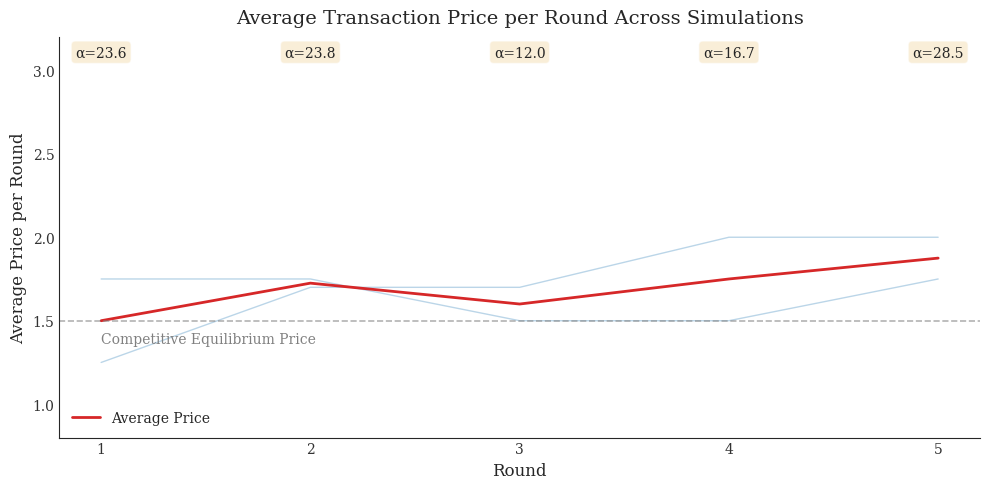

In [48]:
df_transactions_all = df_data_all.loc[df_data_all['transaction_made']==True].reset_index()
sim_round_avg = df_transactions_all.groupby(['sim', 'round'])['price'].agg(['mean', 'std', 'count']).reset_index()
df_plot = sim_round_avg.pivot_table(index='round', columns='sim', values='mean')

# --- Compute average alpha per round across simulations ---
avg_alpha = (
    coefficients_of_convergence
    .groupby('round')['coefficient_of_convergence']
    .mean()
)

fig, ax = plt.subplots(figsize=(10,5))

sim_color = '#1f77b4'
avg_color = '#d62728'

for sim_id in df_plot.columns:
    ax.plot(df_plot.index, df_plot[sim_id], color=sim_color, alpha=0.3, linewidth=1)

avg_prices = df_plot.mean(axis=1)
ax.plot(df_plot.index, avg_prices, color=avg_color, linewidth=2, label='Average Price')

ax.axhline(y=p_eq, color='grey', linestyle='--', linewidth=1.2, alpha=0.6)
ax.text(df_plot.index[0], p_eq - 0.15, 'Competitive Equilibrium Price',
        color='grey', fontsize=10, family='serif', va='bottom')

# --- Add average alpha annotation per round ---
for round_num, alpha_value in avg_alpha.items():
    ax.text(round_num, 3.15, f'α={alpha_value:.1f}',
            ha='center', va='top', fontsize=10, family='serif',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.5))

ax.set_xlabel('Round', fontsize=12, family='serif')
ax.set_ylabel('Average Price per Round', fontsize=12, family='serif')
ax.set_title('Average Transaction Price per Round Across Simulations',
             fontsize=14, family='serif', pad=10)

ax.tick_params(axis='both', direction='in', labelsize=10, colors='#333333')
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_family('serif')
ax.set_xticks(df_plot.index) 

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)

ax.set_ylim(0.8, 3.2)

ax.legend(loc='lower left', frameon=False, prop={'family': 'serif', 'size': 10})
ax.grid(False)

plt.tight_layout()
plt.show()

### Determine Submarginal Buyers/Sellers

In [15]:
# no. of submarginal sellers (reservation_price > theoretical equilibrium price)
submarginal_sellers_number = (supply>p_eq).sum()

# no. of submarginal buyers (reservation_price < theoretical equilibrium price)
submarginal_buyers_number = (demand<p_eq).sum()

# no. of submarginal sellers and buyers who made contracts
df = df_transactions_all.loc[df_transactions_all["announcement_type"]=="sell"]
result_sellers_announcers = df.groupby(['sim', 'round']).apply(lambda x: (x['announcing_agent_reservation_price'] > x['equilibrium_price']).sum(), include_groups=False)
result_buyers_responders = df.groupby(['sim', 'round']).apply(lambda x: (x['responding_agent_reservation_price'] < x['equilibrium_price']).sum(), include_groups=False)
df = df_transactions_all.loc[df_transactions_all["announcement_type"]=="buy"]
result_buyers_announcers = df.groupby(['sim', 'round']).apply(lambda x: (x['announcing_agent_reservation_price'] < x['equilibrium_price']).sum(), include_groups=False)
result_sellers_responders = df.groupby(['sim', 'round']).apply(lambda x: (x['responding_agent_reservation_price'] > x['equilibrium_price']).sum(), include_groups=False)
combined_sellers = (result_sellers_announcers + result_sellers_responders).fillna(0).reset_index()
combined_buyers = (result_buyers_announcers + result_buyers_responders).fillna(0).reset_index()

# merge the buyers and sellers dfs
combined_sellers = combined_sellers.rename(columns={0: "number of submarginal sellers who transacted"})
combined_buyers = combined_buyers.rename(columns={0: "number of submarginal buyers who transacted"})
submarginal_transactions_summary = combined_sellers.merge(combined_buyers, on=['sim', 'round'])
submarginal_transactions_summary = submarginal_transactions_summary.astype(int)

### Market Summary Table (with each simulation shown separately)

In [ ]:
### prepare an equivalent to Table 1 in Smith (1962)

# combine the coefficient of convergence with the submarginal buyers/sellers who actually transaceted
df_market_summary = coefficients_of_convergence.merge(submarginal_transactions_summary, on=['sim', 'round'])
df_market_summary["coefficient_of_convergence"] = df_market_summary["coefficient_of_convergence"].round(1)
df_market_summary

# add the average price in the round
df_mean_price = df_transactions_all.groupby(["sim", "round"])["price"].mean().reset_index().rename(columns={"price": "average price"})
df_market_summary = df_market_summary.merge(df_mean_price, on=['sim', 'round'])

# add the number of transactions
df_transaction_number = df_transactions_all.groupby(["sim", "round"])["price"].count().reset_index().rename(columns={"price": "number of transactions"})
df_market_summary = df_market_summary.merge(df_transaction_number, on=['sim', 'round'])

# add static equilibrium values
df_market_summary["equilibrium_price"] = p_eq
df_market_summary["equilibrium_quantity"] = q_eq
df_market_summary["no of submarginal buyers"] = submarginal_buyers_number
df_market_summary["no of submarginal sellers"] = submarginal_sellers_number

# print
df_market_summary = df_market_summary[["sim", "round", "equilibrium_quantity", "number of transactions", 
                                       "equilibrium_price", "average price", "coefficient_of_convergence",
                                       "no of submarginal buyers", "number of submarginal buyers who transacted",
                                       "no of submarginal sellers", "number of submarginal sellers who transacted"]]
df_market_summary

,sim,round,equilibrium_quantity,number of transactions,equilibrium_price,average price,coefficient_of_convergence,no of submarginal buyers,number of submarginal buyers who transacted,no of submarginal sellers,number of submarginal sellers who transacted
0,1,1,2,2,1.5,1.25,23.6,1,1,1,0
1,1,2,2,2,1.5,1.70,24.0,1,0,1,1
2,1,3,2,2,1.5,1.70,24.0,1,0,1,1
3,1,4,2,1,1.5,2.00,33.3,1,0,1,0
4,1,5,2,1,1.5,2.00,33.3,1,0,1,0
5,2,1,2,2,1.5,1.75,23.6,1,0,1,1
6,2,2,2,2,1.5,1.75,23.6,1,0,1,0
7,2,3,2,2,1.5,1.50,0.0,1,0,1,0
8,2,4,2,2,1.5,1.50,0.0,1,0,1,0
9,2,5,2,2,1.5,1.75,23.6,1,0,1,0


### Market Summary Table (Averaged Across Simulations)

In [43]:
df_market_summary_mean_sim = df_market_summary.groupby(["round"]).mean().drop("sim", axis=1)
df_market_summary_mean_sim

,equilibrium_quantity,number of transactions,equilibrium_price,average price,coefficient_of_convergence,no of submarginal buyers,number of submarginal buyers who transacted,no of submarginal sellers,number of submarginal sellers who transacted
round,,,,,,,,,
1,2.0,2.0,1.5,1.500,23.60,1.0,0.5,1.0,0.5
2,2.0,2.0,1.5,1.725,23.80,1.0,0.0,1.0,0.5
3,2.0,2.0,1.5,1.600,12.00,1.0,0.0,1.0,0.5
4,2.0,1.5,1.5,1.750,16.65,1.0,0.0,1.0,0.0
5,2.0,1.5,1.5,1.875,28.45,1.0,0.0,1.0,0.0


# Analyse Announcements

## Summarise each announcement

In [17]:
# summarize announcements in a single dataframe (collapse the responses into a single row)
df_announcements = df_data_all.groupby(['sim', 'round', 'iteration', 'announcement_type', 'announcing_agent_id'],
                as_index=False, sort=False).agg({
                    'price': 'first',
                    'announcement_made': 'count',
                    'announcing_agent_reservation_price': 'first',
                    'transaction_made': 'last'})

df_announcements = df_announcements.rename(columns={'announcement_made': 'n_responses'})

# create masks
buy_mask = df_announcements['announcement_type'] == 'buy'
sell_mask = df_announcements['announcement_type'] == 'sell'

df_announcements

,sim,round,iteration,announcement_type,announcing_agent_id,price,n_responses,announcing_agent_reservation_price,transaction_made
0,1,1,1,buy,0.0,1.0,1,1.0,True
1,1,1,2,sell,4.0,1.5,1,1.5,True
2,1,1,3,buy,1.0,1.4,1,1.5,False
3,1,1,3,sell,5.0,2.0,1,2.0,False
4,1,2,1,sell,5.0,2.0,1,2.0,True
...,...,...,...,...,...,...,...,...,...
61,2,4,3,sell,5.0,2.0,1,2.0,False
62,2,5,1,sell,4.0,2.0,1,1.5,True
63,2,5,2,buy,1.0,1.5,2,1.5,True
64,2,5,3,buy,0.0,1.0,1,1.0,False


## Analyse Announcement Deviations from Reservation Price by Agent Type

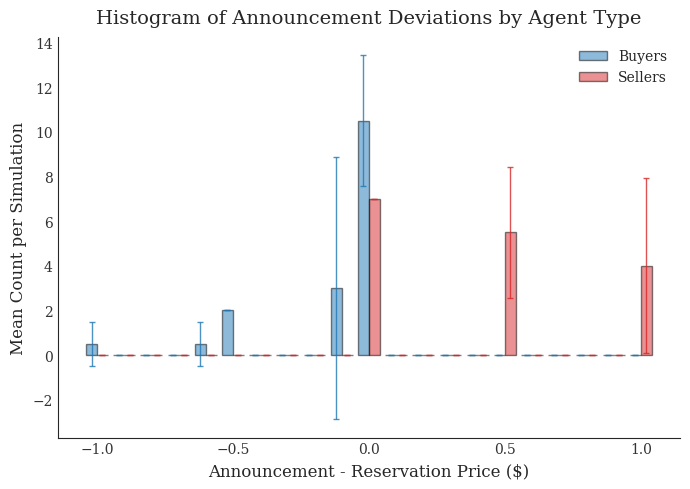

In [52]:
# Copy data and compute deviation
df_plot = df_announcements.copy()
df_plot['deviation'] = df_plot['price'] - df_plot['announcing_agent_reservation_price']

# Define bins symmetric around zero
max_dev = np.max(np.abs(df_plot['deviation']))
num_bins = 20
bin_width = (2 * max_dev) / num_bins
bins = np.arange(-max_dev - bin_width/2, max_dev + bin_width, bin_width)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

# Function to compute mean & CI across simulations
def compute_hist_ci(data, mask, value_col, bins):
    sims = data['sim'].unique()
    counts_per_sim = []
    for sim_id in sims:
        vals = data.loc[(data['sim'] == sim_id) & mask, value_col]
        counts, _ = np.histogram(vals, bins=bins, density=False)
        counts_per_sim.append(counts)
    counts_per_sim = np.array(counts_per_sim)
    mean_counts = counts_per_sim.mean(axis=0)
    se = counts_per_sim.std(axis=0, ddof=1) / np.sqrt(len(sims))
    ci95 = 1.96 * se
    return mean_counts, ci95

# Compute buyers and sellers histograms + CIs
buyers_mean, buyers_ci = compute_hist_ci(df_plot, buy_mask, 'deviation', bins)
sellers_mean, sellers_ci = compute_hist_ci(df_plot, sell_mask, 'deviation', bins)

# --- Plot ---
sns.set_style("white")
fig, ax = plt.subplots(figsize=(7,5))

# Set width and offset for side-by-side bars
bar_width = bin_width * 0.4  # Each bar takes 40% of bin width
offset = bin_width * 0.2     # Offset from center

# Buyers (offset to the left)
ax.bar(
    bin_centers - offset, buyers_mean,
    width=bar_width, color='#1f77b4', alpha=0.5,
    edgecolor='k', label='Buyers'
)

# Sellers (offset to the right)
ax.bar(
    bin_centers + offset, sellers_mean,
    width=bar_width, color='#d62728', alpha=0.5,
    edgecolor='k', label='Sellers'
)

# Draw CI for ALL bins (adjusted positions)
ax.errorbar(
    bin_centers - offset, buyers_mean,
    yerr=buyers_ci,
    fmt='none', ecolor='#1f77b4', elinewidth=1, capsize=2, alpha=0.8
)
ax.errorbar(
    bin_centers + offset, sellers_mean,
    yerr=sellers_ci,
    fmt='none', ecolor='#d62728', elinewidth=1, capsize=2, alpha=0.8
)

# Optional zero line
# ax.axvline(0, color='k', linestyle='--', linewidth=1)

# Axis labels and title
ax.set_xlabel("Announcement - Reservation Price ($)", fontsize=12, family='serif')
ax.set_ylabel("Mean Count per Simulation", fontsize=12, family='serif')
ax.set_title("Histogram of Announcement Deviations by Agent Type",
             fontsize=14, family='serif', pad=10)

# Tick styling
ax.tick_params(axis='both', direction='in', labelsize=10, colors='#333333')
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_family('serif')

# Spines and legend
for side in ['top', 'right']:
    ax.spines[side].set_visible(False)
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)
ax.legend(loc='upper right', frameon=False, prop={'family': 'serif', 'size': 10})

ax.grid(False)
fig.tight_layout()
plt.show()

## Compare the evolution of bids and offers in a single simulation

### Bids vs offers over time

C:\Users\pauls\AppData\Local\Temp\ipykernel_24632\2512230552.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_buy = df_plot[buy_mask & (df_plot['sim']==sim)]
C:\Users\pauls\AppData\Local\Temp\ipykernel_24632\2512230552.py:11: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_sell = df_plot[sell_mask & (df_plot['sim']==sim)]


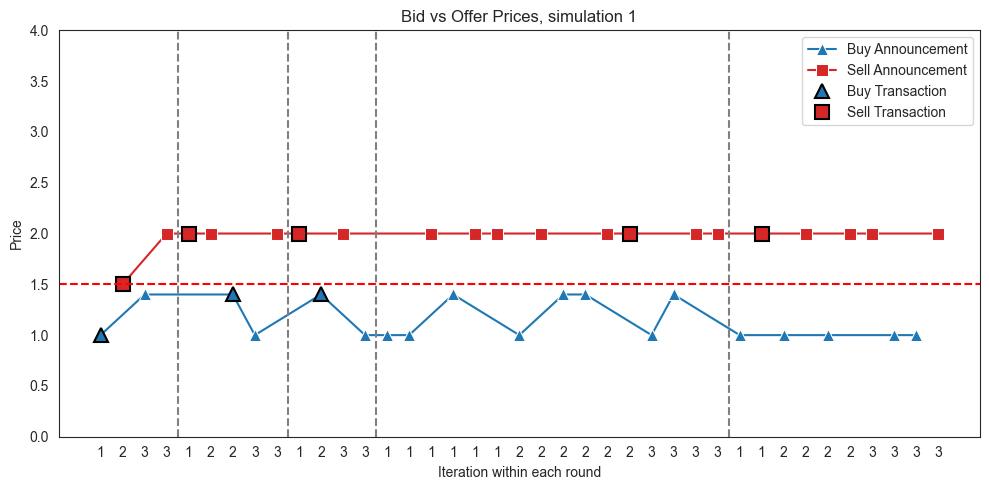

In [50]:
# Plot Announcement vs Transaction Prices for a single simulation

# choose simulation
sim = 1

df_plot = df_announcements.loc[df_announcements['sim']==sim]
plt.figure(figsize=(10, 5))

# Split data by buy/sell type
df_buy = df_plot[buy_mask & (df_plot['sim']==sim)]
df_sell = df_plot[sell_mask & (df_plot['sim']==sim)]

# --- Plot ALL announcements by type WITH connecting lines ---
sns.lineplot(
    x=df_buy.index, 
    y='price', 
    data=df_buy, 
    marker='^',  # Triangle for buy
    markersize=8,
    linestyle='-',  # Connect with lines
    label='Buy Announcement',
    color='#1f77b4'
)

sns.lineplot(
    x=df_sell.index, 
    y='price', 
    data=df_sell, 
    marker='s',  # Square for sell
    markersize=8,
    linestyle='-',  # Connect with lines
    label='Sell Announcement',
    color='#d62728'
)

# --- Plot TRANSACTIONS by type ---
df_buy_trans = df_buy[df_buy['transaction_made'] == True]
df_sell_trans = df_sell[df_sell['transaction_made'] == True]

sns.lineplot(
    x=df_buy_trans.index,
    y='price', 
    data=df_buy_trans, 
    marker='^',  # Triangle for buy
    markersize=10,
    markeredgecolor='black',
    markeredgewidth=1.5,
    linestyle='',  # No line for transactions
    label='Buy Transaction',
    color='#1f77b4'
)

sns.lineplot(
    x=df_sell_trans.index,
    y='price', 
    data=df_sell_trans, 
    marker='s',  # Square for sell
    markersize=10,
    markeredgecolor='black',
    markeredgewidth=1.5,
    linestyle='',  # No line for transactions
    label='Sell Transaction',
    color='#d62728'
)

# --- Formatting ---
last_indices_in_round = df_plot.groupby('round')['iteration'].apply(lambda g: g.index.max())
for x in last_indices_in_round[:-1]:
    plt.axvline(x=x+0.5, color='grey', linestyle='--', linewidth=1.5)
plt.axhline(y=1.5, color='red', linestyle='--')
plt.xticks(ticks=df_plot.index, labels=df_plot['iteration'], rotation=0)
plt.title(f'Bid vs Offer Prices, simulation {sim}')
plt.xlabel('Iteration within each round')
plt.ylabel('Price')
plt.ylim(0, 4)
plt.legend()
plt.tight_layout()
plt.show()

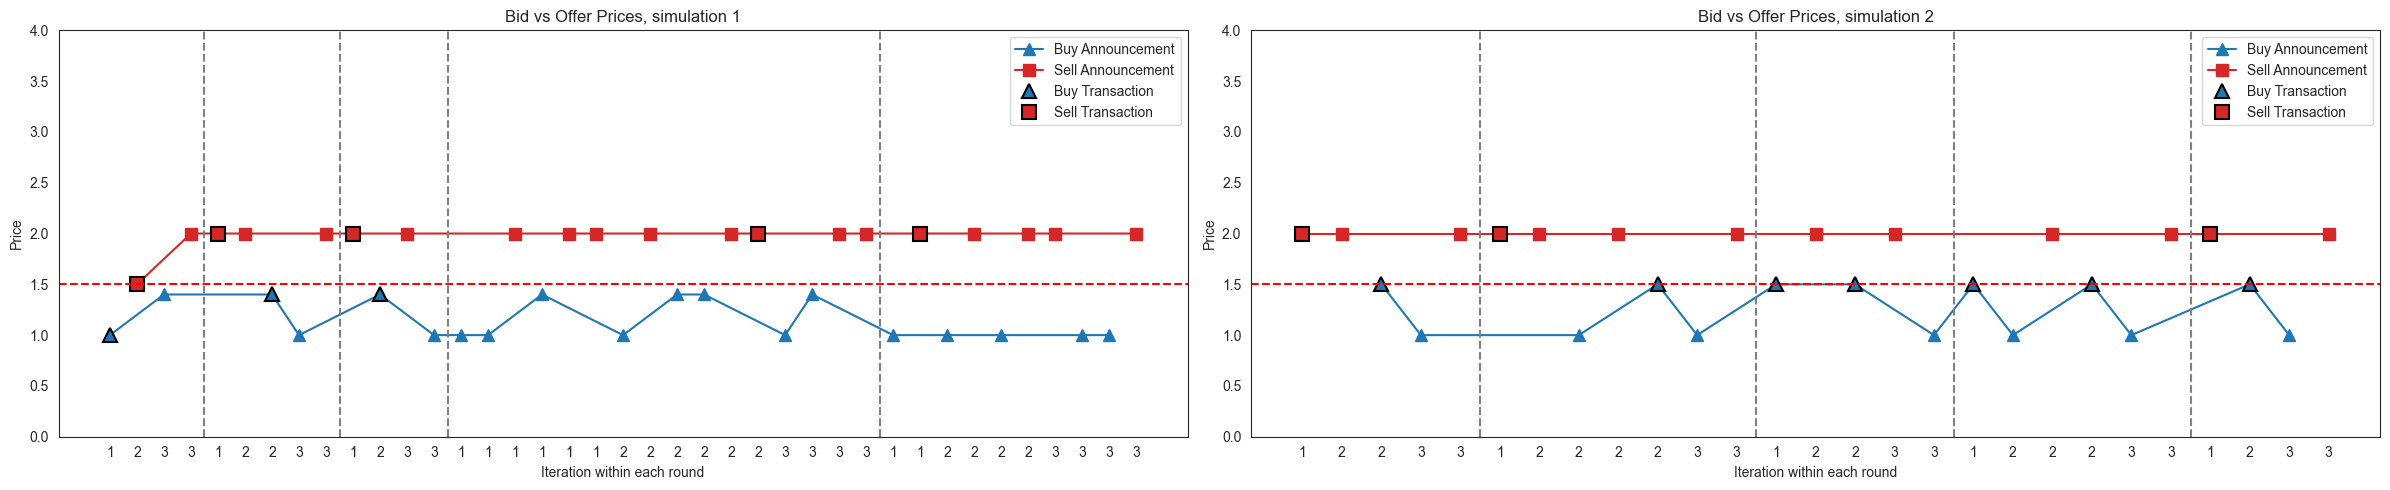

In [54]:
# Plot Announcement vs Transaction Prices for ALL simulations

sims = df_announcements['sim'].unique()
n_sims = len(sims)

# Layout: up to 2 columns
n_cols = 2
n_rows = (n_sims + n_cols - 1) // n_cols  # ceil division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12 * n_cols, 5 * n_rows))
axes = axes.flatten()  # Makes indexing easier regardless of shape

for i, sim in enumerate(sorted(sims)):
    ax = axes[i]

    df_plot = df_announcements[df_announcements['sim'] == sim]

    # Split data by buy/sell type (reindex masks to avoid alignment warning)
    df_buy  = df_plot[buy_mask.reindex(df_plot.index,  fill_value=False)]
    df_sell = df_plot[sell_mask.reindex(df_plot.index, fill_value=False)]

    # --- Plot ALL announcements by type WITH connecting lines ---
    ax.plot(df_buy.index,  df_buy['price'],
            marker='^', markersize=8, linestyle='-',
            label='Buy Announcement', color='#1f77b4')

    ax.plot(df_sell.index, df_sell['price'],
            marker='s', markersize=8, linestyle='-',
            label='Sell Announcement', color='#d62728')

    # --- Plot TRANSACTIONS by type ---
    df_buy_trans  = df_buy[df_buy['transaction_made']   == True]
    df_sell_trans = df_sell[df_sell['transaction_made'] == True]

    ax.plot(df_buy_trans.index, df_buy_trans['price'],
            marker='^', markersize=10, linestyle='',
            markeredgecolor='black', markeredgewidth=1.5,
            label='Buy Transaction', color='#1f77b4')

    ax.plot(df_sell_trans.index, df_sell_trans['price'],
            marker='s', markersize=10, linestyle='',
            markeredgecolor='black', markeredgewidth=1.5,
            label='Sell Transaction', color='#d62728')

    # --- Formatting ---
    last_indices_in_round = df_plot.groupby('round')['iteration'].apply(lambda g: g.index.max())
    for x in last_indices_in_round[:-1]:
        ax.axvline(x=x + 0.5, color='grey', linestyle='--', linewidth=1.5)

    ax.axhline(y=1.5, color='red', linestyle='--')
    ax.set_xticks(df_plot.index)
    ax.set_xticklabels(df_plot['iteration'], rotation=0)
    ax.set_title(f'Bid vs Offer Prices, simulation {sim}')
    ax.set_xlabel('Iteration within each round')
    ax.set_ylabel('Price')
    ax.set_ylim(0, 4)
    ax.legend()

# Hide any unused subplots (if n_sims is odd)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### Bids/Offers vs Transaction Prices

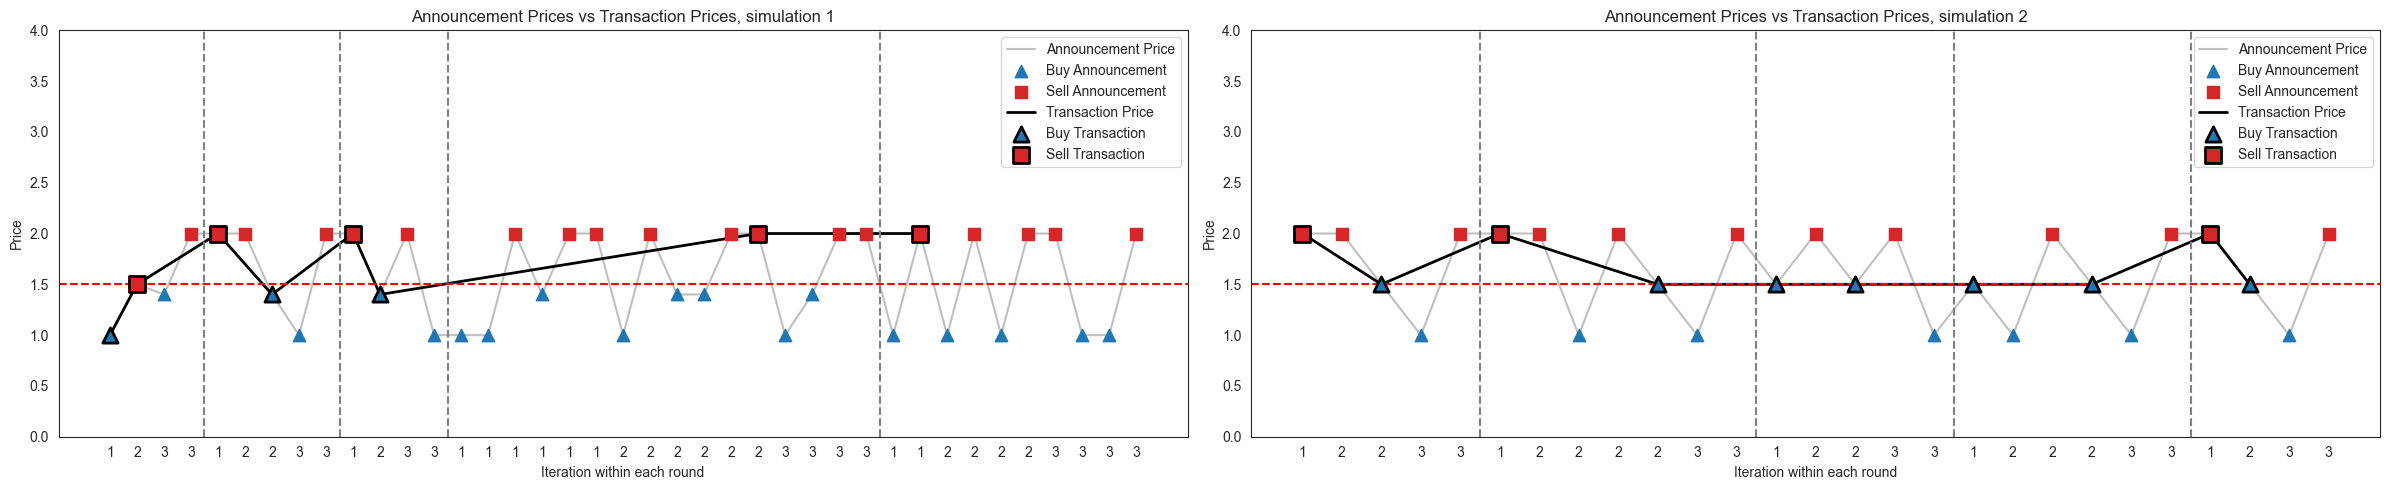

In [56]:
# Plot Announcement Prices vs Transaction Prices for ALL simulations

sims = df_announcements['sim'].unique()
n_sims = len(sims)

# Layout: up to 2 columns
n_cols = 2
n_rows = (n_sims + n_cols - 1) // n_cols  # ceil division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12 * n_cols, 5 * n_rows))
axes = axes.flatten()

for i, sim in enumerate(sorted(sims)):
    ax = axes[i]

    df_plot = df_announcements[df_announcements['sim'] == sim]

    # Split data by buy/sell type (reindex masks to avoid alignment warning)
    df_buy  = df_plot[buy_mask.reindex(df_plot.index,  fill_value=False)]
    df_sell = df_plot[sell_mask.reindex(df_plot.index, fill_value=False)]

    # --- Line connecting ALL announcements ---
    ax.plot(
        df_plot.index,
        df_plot['price'],
        color='gray', alpha=0.5, linewidth=1.5,
        label='Announcement Price', zorder=1
    )

    # --- Markers for buy/sell announcements ---
    ax.scatter(
        df_buy.index, df_buy['price'],
        marker='^', s=80, color='#1f77b4',
        label='Buy Announcement', zorder=3
    )

    ax.scatter(
        df_sell.index, df_sell['price'],
        marker='s', s=80, color='#d62728',
        label='Sell Announcement', zorder=3
    )

    # --- Line connecting ALL transactions ---
    df_transactions = df_plot[df_plot['transaction_made'] == True]
    if len(df_transactions) > 0:
        ax.plot(
            df_transactions.index, df_transactions['price'],
            color='black', linewidth=2,
            label='Transaction Price', zorder=2
        )

        # --- Markers for buy/sell transactions ---
        df_buy_trans  = df_buy[df_buy['transaction_made']   == True]
        df_sell_trans = df_sell[df_sell['transaction_made'] == True]

        ax.scatter(
            df_buy_trans.index, df_buy_trans['price'],
            marker='^', s=120, color='#1f77b4',
            edgecolors='black', linewidths=2,
            label='Buy Transaction', zorder=4
        )

        ax.scatter(
            df_sell_trans.index, df_sell_trans['price'],
            marker='s', s=120, color='#d62728',
            edgecolors='black', linewidths=2,
            label='Sell Transaction', zorder=4
        )

    # --- Formatting ---
    last_indices_in_round = df_plot.groupby('round')['iteration'].apply(lambda g: g.index.max())
    for x in last_indices_in_round[:-1]:
        ax.axvline(x=x + 0.5, color='grey', linestyle='--', linewidth=1.5)

    ax.axhline(y=p_eq, color='red', linestyle='--')
    ax.set_xticks(df_plot.index)
    ax.set_xticklabels(df_plot['iteration'], rotation=0)
    ax.set_title(f'Announcement Prices vs Transaction Prices, simulation {sim}')
    ax.set_xlabel('Iteration within each round')
    ax.set_ylabel('Price')
    ax.set_ylim(0, 4)
    ax.legend()

# Hide any unused subplots (if n_sims is odd)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

# Analyse Responses

## Acceptance rate vs reservation price

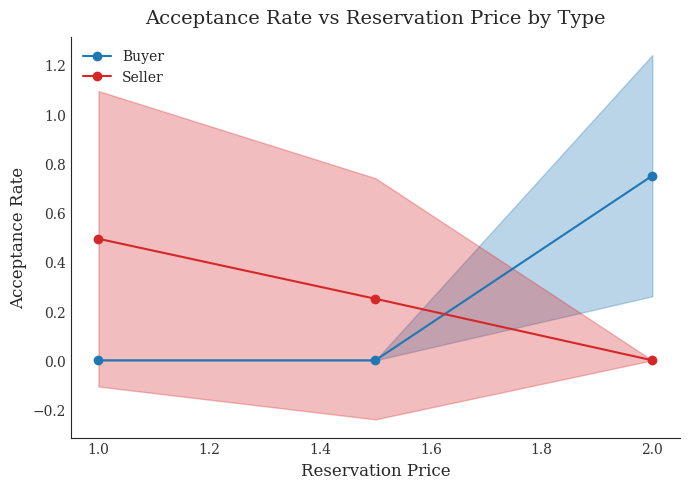

In [27]:
# Plot Acceptance Rate vs Reservation Price with 95% CIs
df = df_data_agents_all.loc[df_data_agents_all['action']=='respond']
df = df.groupby(['sim', 'agent_type', 'agent_id', 'reservation_price', 'outcome']).agg({
    'price': 'count'
}
).reset_index()
df = df.pivot(index=['sim', 'agent_type', 'agent_id', 'reservation_price'], 
                   columns='outcome',
                   values='price').fillna(0)
df['total'] = df['accepted'] + df['rejected']

df['acceptance_rate'] = df['accepted']/df['total']
df = df.reset_index()

# --- Aggregate over simulations ---
agg = df.groupby(['agent_type', 'reservation_price']).agg(
    mean_rate=('acceptance_rate', 'mean'),
    se=('acceptance_rate', lambda x: x.std(ddof=1)/np.sqrt(len(x)))
).reset_index()
agg['ci95'] = 1.96 * agg['se']

# --- Plot ---
sns.set_style("white")
fig, ax = plt.subplots(figsize=(7,5))

types = agg['agent_type'].unique()
colors = {'buyer': '#1f77b4', 'seller': '#d62728'}

for t in types:
    df_t = agg[agg['agent_type'] == t]
    ax.plot(df_t['reservation_price'], df_t['mean_rate'],
            marker='o', color=colors[t], label=t.capitalize())
    ax.fill_between(df_t['reservation_price'],
                    df_t['mean_rate'] - df_t['ci95'],
                    df_t['mean_rate'] + df_t['ci95'],
                    color=colors[t], alpha=0.3)

# Labels and title
ax.set_xlabel("Reservation Price", fontsize=12, family='serif')
ax.set_ylabel("Acceptance Rate", fontsize=12, family='serif')
ax.set_title("Acceptance Rate vs Reservation Price by Type",
             fontsize=14, family='serif', pad=10)

# Tick styling
ax.tick_params(axis='both', direction='in', labelsize=10, colors='#333333')
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_family('serif')

# Spines and legend
for side in ['top', 'right']:
    ax.spines[side].set_visible(False)
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)
ax.legend(loc='upper left', frameon=False, prop={'family': 'serif', 'size':10})

ax.grid(False)
fig.tight_layout()
plt.show()


# Analyse Profits

In [28]:
# construct an implied profit column for each agents action
df_data_agents_all['implied_profit'] = np.where(
    df_data_agents_all['agent_type'] == 'buyer',
    df_data_agents_all['reservation_price'] - df_data_agents_all['price'],  # buyer profit
    df_data_agents_all['price'] - df_data_agents_all['reservation_price']   # seller profit
)

# filter only the accepted offers
df_profits_realized = df_data_agents_all.loc[df_data_agents_all['outcome']=="accepted"].sort_values(by=["sim", "round", "iteration"]).reset_index(drop=True)

# Calculate profits for buyers and sellers per iteration
df = df_profits_realized.copy()
result = df.pivot_table(
    index=['sim', 'round', 'iteration'],
    columns='agent_type',
    values='implied_profit',
    aggfunc='first'
).reset_index()

# Rename the columns for clarity
result.columns.name = None
result = result.rename(columns={
    'buyer': 'buyer_profit',
    'seller': 'seller_profit'
})

# Add the announcer column
announcer = df[df['action'] == 'announce'].set_index(['sim', 'round', 'iteration'])['agent_type']
df_profits = result.merge(
    announcer.rename('announcer'),
    left_on=['sim', 'round', 'iteration'],
    right_index=True,
    how='left'
)

df_profits

,sim,round,iteration,buyer_profit,seller_profit,announcer
0,1,1,1,0.0,0.0,buyer
1,1,1,2,0.5,0.0,seller
2,1,2,1,0.0,0.0,seller
3,1,2,2,0.1,0.4,buyer
4,1,3,1,0.0,0.0,seller
5,1,3,2,0.1,0.4,buyer
6,1,4,2,0.0,0.0,seller
7,1,5,1,0.0,0.0,seller
8,2,1,1,0.0,0.0,seller
9,2,1,2,0.0,0.5,buyer


## Profits by agent type

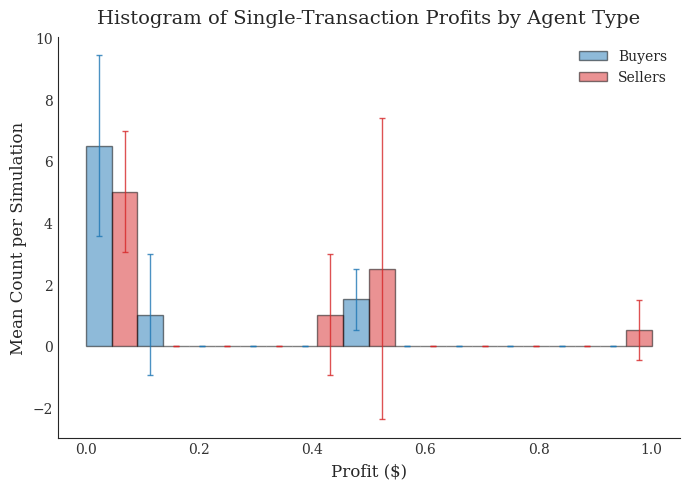

In [29]:
# Histogram of Single Transaction Profits by agent type
# with 95%-CIs
# non-overlapping bars

# Define bin edges
min_profit = df_profits[['buyer_profit','seller_profit']].min().min()
max_profit = df_profits[['buyer_profit','seller_profit']].max().max()

# Bins: negative, zero, then positive
positive_bins = np.linspace(0, max_profit, 12)
bins = np.concatenate(([0], positive_bins[1:]))
bin_centers = 0.5 * (bins[:-1] + bins[1:])
bin_width = np.diff(bins)

# Prepare containers for mean & CI
def hist_with_ci(data, value_col):
    """Compute mean histogram and 95% CI across simulations."""
    sims = data['sim'].unique()
    counts_per_sim = []

    for sim_id in sims:
        vals = data.loc[data['sim'] == sim_id, value_col]
        counts, _ = np.histogram(vals, bins=bins, density=False)
        counts_per_sim.append(counts)

    counts_per_sim = np.array(counts_per_sim)
    mean_counts = counts_per_sim.mean(axis=0)
    se = counts_per_sim.std(axis=0, ddof=1) / np.sqrt(len(sims))
    ci95 = 1.96 * se
    return mean_counts, ci95

# Compute mean and CI for buyers and sellers
buyers_mean, buyers_ci = hist_with_ci(df_profits, 'buyer_profit')
sellers_mean, sellers_ci = hist_with_ci(df_profits, 'seller_profit')

# --- Plot ---
fig, ax = plt.subplots(figsize=(7,5))
sns.set_style("white")

# Buyers (blue)
ax.bar(
    bin_centers - bin_width/4, buyers_mean,
    width=bin_width/2, color='#1f77b4', alpha=0.5,
    edgecolor='k', label='Buyers'
)
ax.errorbar(
    bin_centers - bin_width/4, buyers_mean,
    yerr=buyers_ci, fmt='none', ecolor='#1f77b4',
    elinewidth=1, capsize=2, alpha=0.8
)

# Sellers (red)
ax.bar(
    bin_centers + bin_width/4, sellers_mean,
    width=bin_width/2, color='#d62728', alpha=0.5,
    edgecolor='k', label='Sellers'
)
ax.errorbar(
    bin_centers + bin_width/4, sellers_mean,
    yerr=sellers_ci, fmt='none', ecolor='#d62728',
    elinewidth=1, capsize=2, alpha=0.8
)

# --- Styling ---
ax.set_xlabel("Profit ($)", fontsize=12, family='serif')
ax.set_ylabel("Mean Count per Simulation", fontsize=12, family='serif')
ax.set_title("Histogram of Single-Transaction Profits by Agent Type",
             fontsize=14, family='serif', pad=10)

ax.tick_params(axis='both', direction='in', labelsize=10, colors='#333333')
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_family('serif')

# Spines and legend
for side in ['top', 'right']:
    ax.spines[side].set_visible(False)
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)
ax.legend(loc='upper right', frameon=False, prop={'family': 'serif', 'size': 10})

ax.grid(False)
fig.tight_layout()
plt.show()


# Miscellaneous

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


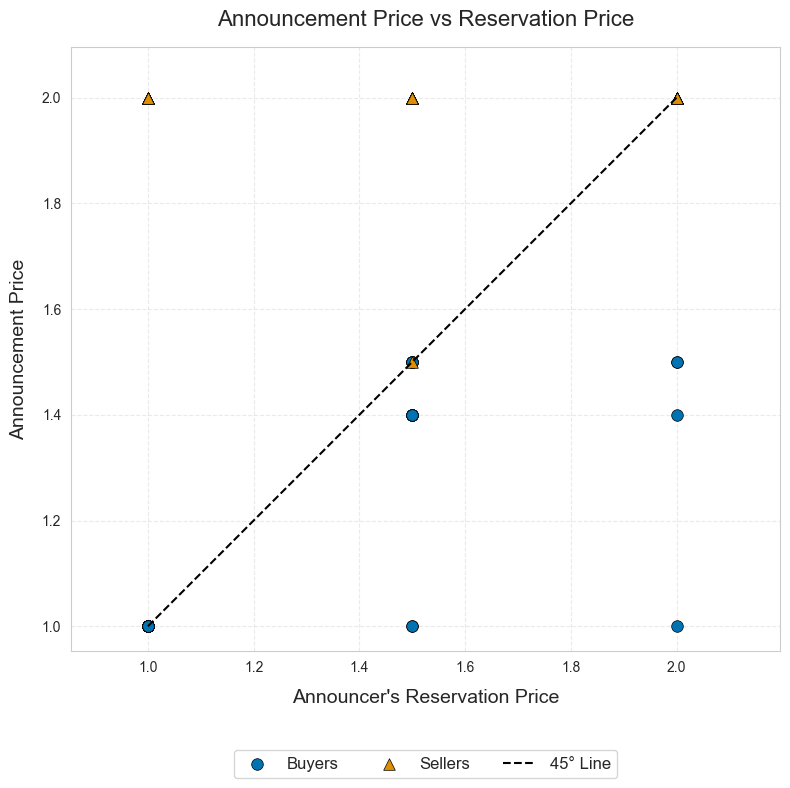

In [31]:
# Plot the announcement price vs reservation price by agent type

with sns.axes_style("whitegrid"):

    # set up figure
    plt.figure(figsize=(8, 8))

    # colors (colorblind-friendly)
    buyer_color = sns.color_palette("colorblind")[0]  # blue
    seller_color = sns.color_palette("colorblind")[1]  # orange

    # scatter plots
    plt.scatter(
        df_announcements.loc[buy_mask, 'announcing_agent_reservation_price'],
        df_announcements.loc[buy_mask, 'price'],
        color=buyer_color, label='Buyers', 
        edgecolor='k', s=70, linewidth=0.5, marker='o'
    )

    plt.scatter(
        df_announcements.loc[sell_mask, 'announcing_agent_reservation_price'],
        df_announcements.loc[sell_mask, 'price'],
        color=seller_color, label='Sellers',
        edgecolor='k', s=70, linewidth=0.5, marker='^'
    )

    # 45-degree line
    min_val = min(df_announcements['announcing_agent_reservation_price'].min(),
                df_announcements['price'].min())
    max_val = max(df_announcements['announcing_agent_reservation_price'].max(),
                df_announcements['price'].max())

    plt.plot([min_val, max_val], [min_val, max_val],
            'k--', linewidth=1.5, label='45° Line')

    # labels and formatting
    plt.xlabel("Announcer's Reservation Price", fontsize=14, labelpad=10)
    plt.ylabel("Announcement Price", fontsize=14, labelpad=10)
    plt.title("Announcement Price vs Reservation Price", fontsize=16, pad=15)
    plt.legend(frameon=True, fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.4)

    # make axes square (for true 45° comparison)
    plt.axis('equal')

    # slightly extend limits
    plt.xlim(min_val * 0.95, max_val * 1.05)
    plt.ylim(min_val * 0.95, max_val * 1.05)

    # tighten layout
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize=12, frameon=True)
    plt.tight_layout()

    plt.show()


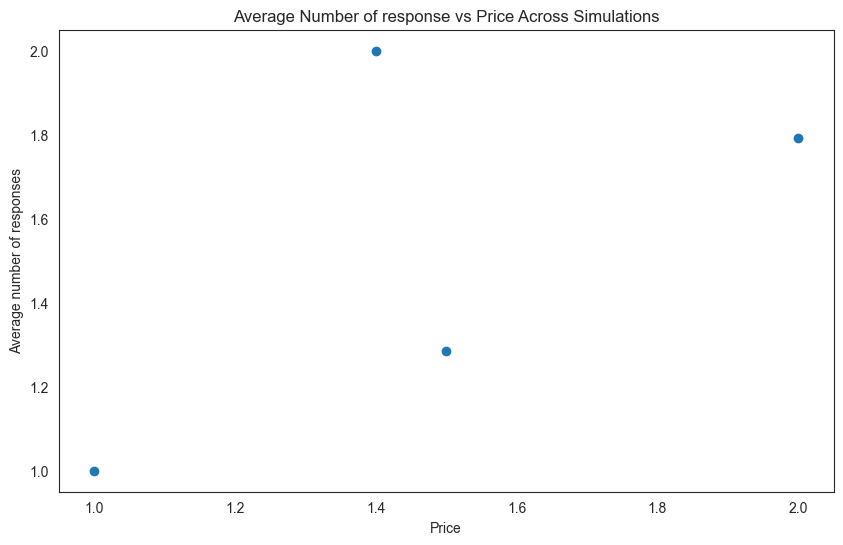

In [32]:
# Plot the mean number of responses as a function of price

# Filter transaction rows
df_plot = df_announcements[df_announcements['transaction_made']==True].copy()

# Compute average n_responses per bin per simulation
bin_stats = df_plot.groupby(['sim', 'price'])['n_responses'].mean().reset_index()

# Now average across simulations
avg_bin_stats = bin_stats.groupby('price')['n_responses'].mean().reset_index()

# Plot
plt.figure(figsize=(10,6))
plt.scatter(avg_bin_stats['price'], avg_bin_stats['n_responses'])
plt.xlabel('Price')
plt.ylabel('Average number of responses')
plt.title('Average Number of response vs Price Across Simulations')
plt.show()
